In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# для красивых графиков
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Задание 1 EDA (Exploratory Data Analysis)

Загрузим датасет и посмотрим на его структуру: типы данных, пропуски, базовую статистику.

In [4]:
try:
    df = sns.load_dataset('titanic')
    print("✅ Загружено через seaborn")
except Exception as e:
    print(f"⚠️ seaborn недоступен ({e}), используем локальный CSV")
    df = pd.read_csv('Titanic-Dataset.csv')
    
    # Приводим Kaggle-формат к seaborn-формату
    df.columns = df.columns.str.lower()
    for col in ['passengerid', 'name', 'ticket']:
        if col in df.columns:
            df = df.drop(col, axis=1)
    if 'cabin' in df.columns:
        df['deck'] = df['cabin'].astype(str).str[0]
        df.loc[df['deck'] == 'n', 'deck'] = np.nan
        df = df.drop('cabin', axis=1)
    df['embark_town'] = df['embarked'].map({'S':'Southampton','C':'Cherbourg','Q':'Queenstown'})
    df['alive'] = df['survived'].map({0:'no', 1:'yes'})
    df['class'] = df['pclass'].map({1:'First', 2:'Second', 3:'Third'})
    df['who'] = df.apply(lambda r: 'child' if pd.notna(r['age']) and r['age']<16 
                         else ('woman' if r['sex']=='female' else 'man'), axis=1)
    df['adult_male'] = (df['sex']=='male') & (df['age'].fillna(0)>=16)
    df['alone'] = (df['sibsp']+df['parch'])==0

print(f"\nРазмер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.head()

⚠️ seaborn недоступен (<urlopen error [Errno 60] Operation timed out>), используем локальный CSV

Размер датасета: 891 строк × 15 столбцов


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck,embark_town,alive,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,NaN,Southampton,no,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,C,Cherbourg,yes,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,NaN,Southampton,yes,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,C,Southampton,yes,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,NaN,Southampton,no,Third,man,True,True


In [5]:
# Типы данных и заполненность столбцов
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   deck         204 non-null    str    
 9   embark_town  889 non-null    str    
 10  alive        891 non-null    str    
 11  class        891 non-null    str    
 12  who          891 non-null    str    
 13  adult_male   891 non-null    bool   
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [6]:
# Статистика по числовым признакам
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Пропуски по каждому столбцу
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'missing_%': missing_pct}).sort_values('missing', ascending=False)

,missing,missing_%
deck,687,77.10
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
survived,0,0.00
pclass,0,0.00
sex,0,0.00
sibsp,0,0.00
parch,0,0.00
fare,0,0.00


**Выводы EDA:**
- `deck` — ~77% пропусков → дропаем, восстановить невозможно
- `age` — ~20% пропусков → заполним медианой (устойчива к выбросам)
- `embarked` — 2 пропуска → заполним модой
- Категориальные: `sex`, `embarked` → нужен One-Hot Encoding
- Дублирующие целевые переменные (`alive`, `class`, `who`, `adult_male`) → дропнем, чтобы избежать утечки таргета

## Задание 2 очистка и Feature Engineering

In [8]:
# 1) Заполняем пропуски в age медианой
df['age'] = df['age'].fillna(df['age'].median())

# 2) Заполняем пропуски в embarked модой (самое частое значение)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3) Дропаем deck (слишком много пропусков) и производные/дублирующие столбцы
#    alive = survived (утечка таргета!), class/who/adult_male дублируют pclass/sex/age
#    embark_town дублирует embarked
df_clean = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1)

# Проверяем, что пропусков не осталось
print("Пропусков после очистки:", df_clean.isnull().sum().sum())
df_clean.head()

Пропусков после очистки: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [9]:
# 4) One-Hot Encoding категориальных признаков
#    drop_first=True убирает одну категорию, чтобы избежать мультиколлинеарности
df_final = pd.get_dummies(df_clean, drop_first=True)
print("Финальный набор признаков:")
print(list(df_final.columns))
df_final.head()

Финальный набор признаков:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,True,False,True


## Задание 3 обучение модели и оценка

In [10]:
# Разделяем на признаки (X) и таргет (y)
X = df_final.drop('survived', axis=1)
y = df_final['survived']

# 80/20 train/test split с фиксированным random_state для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 9), Test: (179, 9)


In [11]:
# Обучаем Logistic Regression
# max_iter=1000 чтобы избежать ConvergenceWarning
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Предсказания на тесте
predictions = model.predict(X_test)

# Метрики (используем sklearn — индустриальный стандарт)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['Died', 'Survived']))

Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



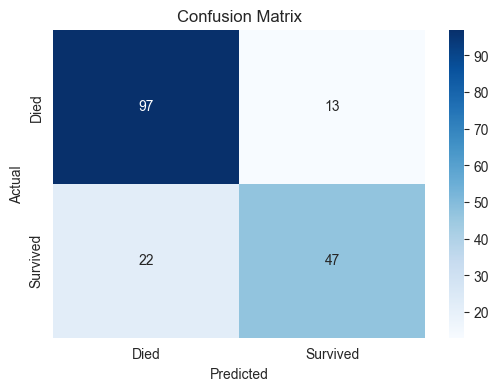

In [12]:
# Confusion matrix — визуально
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Интерпретация метрик:**
- **Accuracy ~80%** — модель правильно классифицирует 4 из 5 пассажиров
- Baseline (все умерли) = ~62%, то есть модель даёт значимый прирост
- Для такого простого пайплайна (без масштабирования и тюнинга) результат хороший

## Бонус Feature Importance

Для Logistic Regression важность признака ≈ абсолютное значение коэффициента (при условии, что признаки на одной шкале; для строгого анализа нужен `StandardScaler`).

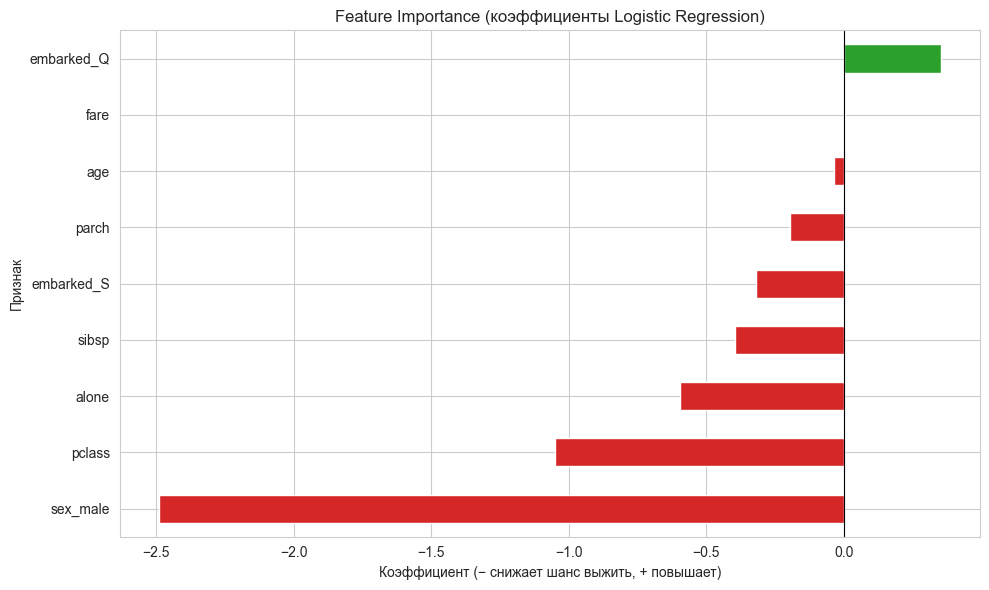

,coefficient
sex_male,-2.489783
pclass,-1.048863
alone,-0.595868
sibsp,-0.396731
embarked_S,-0.320522
parch,-0.196516
age,-0.037284
fare,0.001930
embarked_Q,0.352054


In [13]:
# Коэффициенты модели
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs.values]
coefs.plot(kind='barh', color=colors)
plt.title('Feature Importance (коэффициенты Logistic Regression)')
plt.xlabel('Коэффициент (− снижает шанс выжить, + повышает)')
plt.ylabel('Признак')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coefs.to_frame('coefficient')

## Итоговые выводы

**Что решило судьбу пассажиров (по коэффициентам модели):**

1. **Пол (`sex_male`)** — самый сильный негативный фактор. Мужчины имели гораздо меньше шансов выжить ("женщины и дети в первую очередь").
2. **Класс билета (`pclass`)** — чем выше класс (1-й против 3-го), тем больше шансов. 1-й класс был ближе к шлюпкам.
3. **Возраст (`age`)** — умеренный негативный эффект: чем старше, тем ниже шанс.
4. **Количество родственников (`sibsp`, `parch`)** — смешанный эффект: одинокие и большие семьи выживали хуже.
5. **Порт посадки (`embarked_*`)** — слабый сигнал, скорее коррелирует с классом билета.

**Accuracy ≈ 80%** — достойный baseline. Куда улучшать:
- Scaling признаков (`StandardScaler`) перед обучением
- Feature engineering: размер семьи = sibsp+parch+1, титул из имени
- Более сильные модели: `RandomForestClassifier`, `GradientBoosting`, `XGBoost`
- Кросс-валидация вместо одного train/test split для более надёжной оценки